<!-- reader-content -->

# Hello, drive and readout

This example couples a Duffing transmon to a lossy resonator. First we compare leakage from two qubit pulses; then we drive the resonator and follow its response for qubit $|0\rangle$ and $|1\rangle$.

quchip uses GHz for frequencies and ns for time. The chip and coupling use the RWA in a per-device rotating frame; both drives inherit `chip.rwa=True`.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
from scipy import integrate

from quchip import (
    Capacitive,
    ChargeDrive,
    Chip,
    DuffingTransmon,
    Gaussian,
    GaussianEdge,
    QuantumSequence,
    Resonator,
)

resonator_linewidth = 0.001
truncation_threshold = 1.0e-3

qubit = DuffingTransmon(
    freq=5.0,
    anharmonicity=-0.30,
    levels=6,
    label="qubit",
)
readout = Resonator(
    freq=6.8,
    levels=10,
    quality_factor=6.8 / resonator_linewidth,
    label="readout",
)
chip = Chip(
    [qubit, readout],
    couplings=[
        Capacitive(qubit, readout, g=0.060, rwa=True, label="qubit-readout")
    ],
    frame="rotating",
    rwa=True,
)
qubit_line = ChargeDrive(qubit, label="qubit-charge")
readout_line = ChargeDrive(readout, label="readout-charge")
_ = chip.wire(qubit_line, readout_line)

## Part 1: Qubit drive and leakage

The coupled chip's dressed transitions set the carrier and the neighboring line to avoid. Ask quchip for $f_{01}$ and the dressed $1\rightarrow2$ transition:

In [2]:
f01 = float(chip.freq(qubit))
f12 = float(chip.freq(qubit, when={qubit: 1}))

Both pulses are three-sigma Gaussians with the same nominal-$\pi$ area. The short pulse has bandwidth $|f_{12}-f_{01}|$; the four-times-longer pulse is more selective. `pi_gaussian` rescales each waveform so $2\pi\int E(t)\,dt=\pi$.

In [3]:
drive_durations = 3.0 / (np.pi * abs(f12 - f01)) * np.array([1.0, 4.0])


def pi_gaussian(duration: float) -> Gaussian:
    unit_pulse = Gaussian(duration=duration, sigmas=3.0, amplitude=1.0)
    integration_times = np.linspace(0.0, duration, 20001)
    unit_area = integrate.trapezoid(
        np.asarray(unit_pulse.waveform(integration_times)).real,
        integration_times,
    )
    return Gaussian(
        duration=duration,
        sigmas=3.0,
        amplitude=0.5 / unit_area,
    )


drive_pulses = tuple(pi_gaussian(duration) for duration in drive_durations)
drive_times = np.linspace(0.0, drive_durations[-1], 601)

Both pulses start at $t=0$ from dressed $|0,0\rangle$. The batch varies duration and amplitude on one shared grid; after the short pulse ends, that trajectory evolves freely.

In [4]:
drive_sequence = QuantumSequence(chip)
drive = drive_sequence.schedule(qubit_line, envelope=drive_pulses[0], freq=f01)
drive_batch = drive_sequence.simulate_batch(
    drive_sequence.zip(
        drive.vary("duration", drive_durations, name="duration"),
        drive.vary(
            "amplitude",
            [pulse.amplitude for pulse in drive_pulses],
            name="amplitude",
        ),
    ),
    tlist=drive_times,
    initial_state=chip.state({qubit: 0, readout: 0}),
    progress=False,
    truncation_threshold=truncation_threshold,
)

## Inspect the batch with Quchip

Each batch element is a `SimulationResult`. With `trace_out=readout`, `plot_populations` shows the qubit populations directly. The first result contains the short pulse followed by idle evolution.

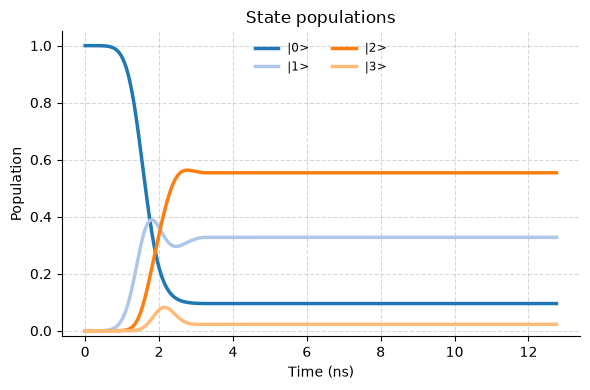

In [5]:
drive_batch[0].plot_populations(trace_out=readout)
plt.show()

The second result is the long pulse, which fills the shared window.

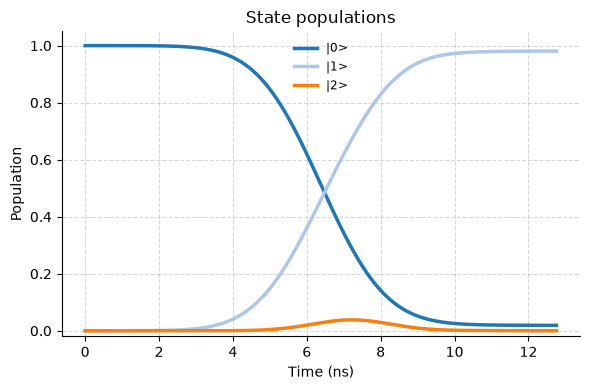

In [6]:
drive_batch[1].plot_populations(trace_out=readout)
plt.show()

## Customize the comparison

For the shared-grid comparison, read $P_0$, $P_1$, and $P_2$ from the batch. Each call returns an array indexed by `(pulse, time)`.

In [7]:
drive_populations = np.asarray(
    [drive_batch.population(qubit, level) for level in range(3)]
).real
drive_receipt = {
    "drive_plot": "../docs/images/hello_qubit_drive_leakage.png",
    "durations_ns": dict(zip(("short", "long"), drive_durations, strict=True)),
    "f01_ghz": f01,
    "f12_ghz": f12,
    "final_p1": dict(
        zip(
            ("short", "long"),
            drive_batch.population(qubit, 1, reduce="last"),
            strict=True,
        )
    ),
    "peak_p2": dict(
        zip(
            ("short", "long"),
            drive_batch.population(qubit, 2, reduce="max"),
            strict=True,
        )
    ),
}

The panels show the actual scheduled envelopes and $P(|0\rangle)$, $P(|1\rangle)$, and $P(|2\rangle)$. The short pulse reaches the adjacent transition; the long pulse suppresses that leakage.

RESULT drive={"drive_plot":"../docs/images/hello_qubit_drive_leakage.png","durations_ns":{"long":12.756614901496675,"short":3.189153725374169},"f01_ghz":4.998002217297629,"f12_ghz":4.698571791302929,"final_p1":{"long":0.9808187222382814,"short":0.3276058450078832},"peak_p2":{"long":0.03843061416534819,"short":0.5631356326693658}}


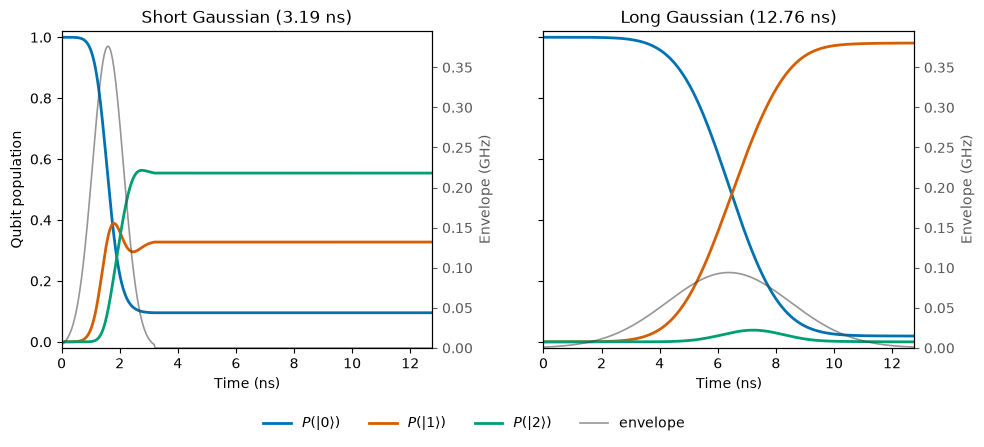

In [8]:
state_colors = ("#0072B2", "#D55E00", "#009E73")
drive_figure, drive_axes = plt.subplots(
    1, 2, figsize=(11.0, 4.8), sharex=True, sharey=True
)
for pulse_index, (axis, name, duration, envelope) in enumerate(
    zip(drive_axes, ("short", "long"), drive_durations, drive_pulses, strict=True)
):
    for level, color in enumerate(state_colors):
        axis.plot(
            drive_times, drive_populations[level, pulse_index],
            color=color, linewidth=2.0, label=fr"$P(|{level}\rangle)$",
        )
    envelope_axis = axis.twinx()
    envelope_axis.plot(
        drive_times,
        np.where(
            drive_times <= duration, envelope.sample(drive_times, real=True), 0.0
        ),
        color="0.25", linewidth=1.2, alpha=0.55, label="envelope",
    )
    envelope_axis.set_ylim(0.0, 1.05 * max(pulse.amplitude for pulse in drive_pulses))
    envelope_axis.set_ylabel("Envelope (GHz)", color="0.35")
    envelope_axis.tick_params(axis="y", colors="0.35")
    axis.set(
        xlim=(0.0, drive_durations[-1]),
        ylim=(-0.02, 1.02),
        xlabel="Time (ns)",
    )
    axis.set_title(f"{name.capitalize()} Gaussian ({duration:.2f} ns)")
    if pulse_index == 0:
        axis.set_ylabel("Qubit population")
        state_handles, state_labels = axis.get_legend_handles_labels()
        envelope_handles, envelope_labels = envelope_axis.get_legend_handles_labels()

drive_figure.legend(
    state_handles + envelope_handles,
    state_labels + envelope_labels,
    frameon=False,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncols=4,
)
drive_figure.subplots_adjust(bottom=0.22, wspace=0.30)

print(f"RESULT drive={json.dumps(drive_receipt, sort_keys=True, separators=(',', ':'))}")
drive_figure.savefig(drive_receipt["drive_plot"], dpi=180)
plt.show()

## Part 2: Dispersive readout

The resonator frequency depends on whether the qubit is in $|0\rangle$ or $|1\rangle$. Ask quchip for both conditional frequencies:

In [9]:
readout_frequencies = (
    float(chip.freq(readout, when={qubit: 0})),
    float(chip.freq(readout, when={qubit: 1})),
)

The readout lasts for the larger of five resonator lifetimes and half the inverse conditional pull, rounded up to the 5 ns grid. Its amplitude is set directly.

In [10]:
readout_time_step = 5.0
readout_duration = readout_time_step * np.ceil(
    max(
        5.0 / (2.0 * np.pi * resonator_linewidth),
        1.0 / (2.0 * abs(readout_frequencies[1] - readout_frequencies[0])),
    )
    / readout_time_step
)
readout_times = np.linspace(
    0.0,
    readout_duration,
    int(round(readout_duration / readout_time_step)) + 1,
)

Schedule that pulse and simulate both prepared states in one quchip batch:

In [11]:
readout_sequence = QuantumSequence(chip)
readout_sequence.schedule(
    readout_line,
    envelope=GaussianEdge(
        duration=readout_duration,
        edge_duration=40.0,
        sigmas=3,
        amplitude=0.0012,
    ),
    freq=sum(readout_frequencies) / 2.0,
)
readout_batch = readout_sequence.simulate_batch(
    readout_sequence.vary(
        "initial_state",
        [
            chip.state({qubit: 0, readout: 0}),
            chip.state({qubit: 1, readout: 0}),
        ],
        name="prepared_qubit",
    ),
    tlist=readout_times,
    e_ops=chip.e_ops(readout="a"),
    progress=False,
    truncation_threshold=truncation_threshold,
)

The solver returns $\alpha(t)=\langle a\rangle$; its real and imaginary parts trace the IQ response for each prepared state.

In [12]:
alpha = np.asarray(readout_batch.expect("readout"), dtype=complex)
readout_receipt = {
    "conditional_resonator_frequencies_ghz": readout_frequencies,
    "final_iq_separation": float(abs(alpha[0, -1] - alpha[1, -1])),
    "iq_plot": "../docs/images/hello_dispersive_readout_iq.png",
    "readout_carrier_ghz": sum(readout_frequencies) / 2.0,
    "readout_duration_ns": readout_duration,
    "solver": readout_batch[0].solver,
}

Plot both paths on equal $I/Q$ scales and mark their final points.

RESULT readout={"conditional_resonator_frequencies_ghz":[6.801997782702374,6.801428548310603],"final_iq_separation":0.8922487554011225,"iq_plot":"../docs/images/hello_dispersive_readout_iq.png","readout_carrier_ghz":6.801713165506488,"readout_duration_ns":880.0,"solver":"mesolve"}


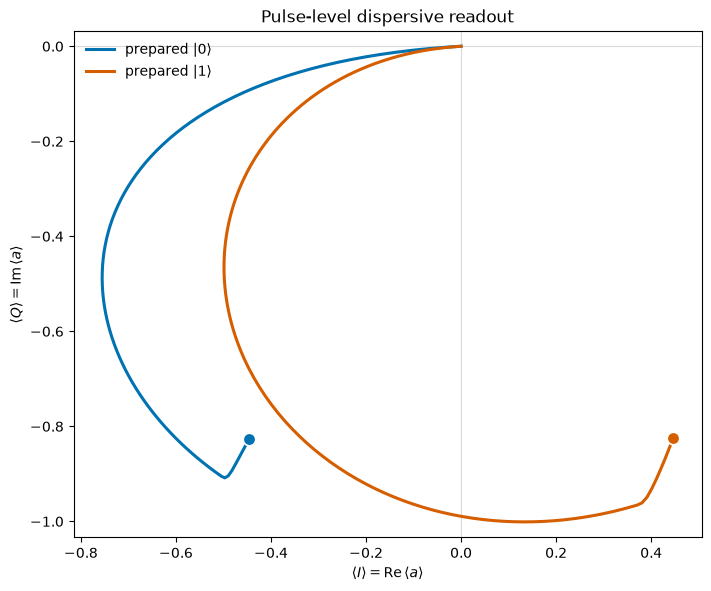

In [13]:
iq_figure, iq_axis = plt.subplots(figsize=(7.0, 5.8), layout="constrained")

for prepared_level, color in enumerate(("#0072B2", "#D55E00")):
    iq_axis.plot(
        alpha[prepared_level].real,
        alpha[prepared_level].imag,
        color=color,
        linewidth=2.2,
        label=fr"prepared $|{prepared_level}\rangle$",
    )
    iq_axis.plot(
        alpha[prepared_level, -1].real,
        alpha[prepared_level, -1].imag,
        marker="o",
        markersize=9,
        markeredgecolor="white",
        markeredgewidth=1.2,
        color=color,
        linestyle="none",
    )

iq_axis.axhline(0.0, color="0.85", linewidth=0.8, zorder=0)
iq_axis.axvline(0.0, color="0.85", linewidth=0.8, zorder=0)
iq_axis.set_xlabel(r"$\langle I\rangle = \mathrm{Re}\,\langle a\rangle$")
iq_axis.set_ylabel(r"$\langle Q\rangle = \mathrm{Im}\,\langle a\rangle$")
iq_axis.set_title("Pulse-level dispersive readout")
iq_axis.set_aspect("equal", adjustable="datalim")
iq_axis.legend(frameon=False, loc="upper left")

print(f"RESULT readout={json.dumps(readout_receipt, sort_keys=True, separators=(',', ':'))}")
iq_figure.savefig(readout_receipt["iq_plot"], dpi=180)
plt.show()

One chip now shows both effects: pulse bandwidth controls leakage, and the qubit state shifts the resonator response.